In [1]:
#Project to build 
#An end-to-end deep learning system that can predict where someone is standing inside a building using only the WiFi signals their device detects.


#Project Member: Shaeekh Al Jahan
#Declarion of AI: Took help from GPT to generate graphs and format descriptions

#_____Phase 1______
#Dataset Description: The UJIIndoorLoc dataset contains around ~20,000 real fingerprint samples collected across 3 university buildings in Spain.
#Each sample records signal strength (RSSI) from 520 access points, along with the exact longitude, latitude, and floor where the measurement was taken.

# UJIIndoorLoc — Phase 1: Data Exploration & Preprocessing

**Goal:** Load the dataset, understand its structure, handle the `100` sentinel values, normalize RSSI readings, and produce clean PyTorch tensors ready for Phase 2. Sentinel value is the case when a rssi reading is missing 

---

## Dataset Quick Facts
| Property | Value |
|---|---|
| Training samples | ~19,937 |
| Validation samples | ~1,111 |
| WiFi access points | 520 |
| RSSI range (real) | −104 dBm → 0 dBm |
| Sentinel value | **100** (AP not detected — specific to this copy) |
| Output targets | LONGITUDE, LATITUDE (x, y) |
| Extra labels | FLOOR, BUILDINGID, SPACEID, … |

---
## 1.0  Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import json
import pickle
import warnings
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader, random_split

warnings.filterwarnings('ignore')

# ── File paths ────────────────────────────────────────────────────────────────
TRAIN_PATH = r'I:\1_Memphis_Sp26\Machine_Learning\Project\archive\TrainingData.csv'
VAL_PATH   = r'I:\1_Memphis_Sp26\Machine_Learning\Project\archive\ValidationData.csv'

# ── Dataset constants ─────────────────────────────────────────────────────────
RSSI_SENTINEL = 100      # 'AP not detected' sentinel in this dataset copy
RSSI_MIN      = -104     # lowest real RSSI observable
RSSI_MAX      = 0        # highest real RSSI observable

TARGET_COLS = ['LONGITUDE', 'LATITUDE']
META_COLS   = ['FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION',
               'USERID', 'PHONEID', 'TIMESTAMP']

# ── Training config ───────────────────────────────────────────────────────────
BATCH_SIZE  = 256
VAL_SPLIT   = 0.15
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('Imports OK')
print(f'PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}')

Imports OK
PyTorch 2.9.1+cpu  |  CUDA available: False


---
## 1.1  Load Data

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)

wap_cols = [c for c in train_df.columns if c.startswith('WAP')]

print(f'Training set   : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Validation set : {val_df.shape[0]:,} rows x {val_df.shape[1]} columns')
print(f'WAP columns    : {len(wap_cols)}')
print(f'Other columns  : {[c for c in train_df.columns if not c.startswith("WAP")]}')

Training set   : 19,937 rows x 529 columns
Validation set : 1,111 rows x 529 columns
WAP columns    : 520
Other columns  : ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']


In [4]:
# Sanity check: confirm sentinel is 100
print('Top value counts in first row')
print(train_df[wap_cols].iloc[0].value_counts().head(10))

Top value counts in first row
0
 100    503
-68       3
-91       2
-81       2
-67       1
-78       1
-79       1
-92       1
-95       1
-89       1
Name: count, dtype: int64


In [5]:
train_df.head(3)

,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095


---
## 1.2  Exploratory Data Analysis

### 1.2.1  Spatial distribution of samples

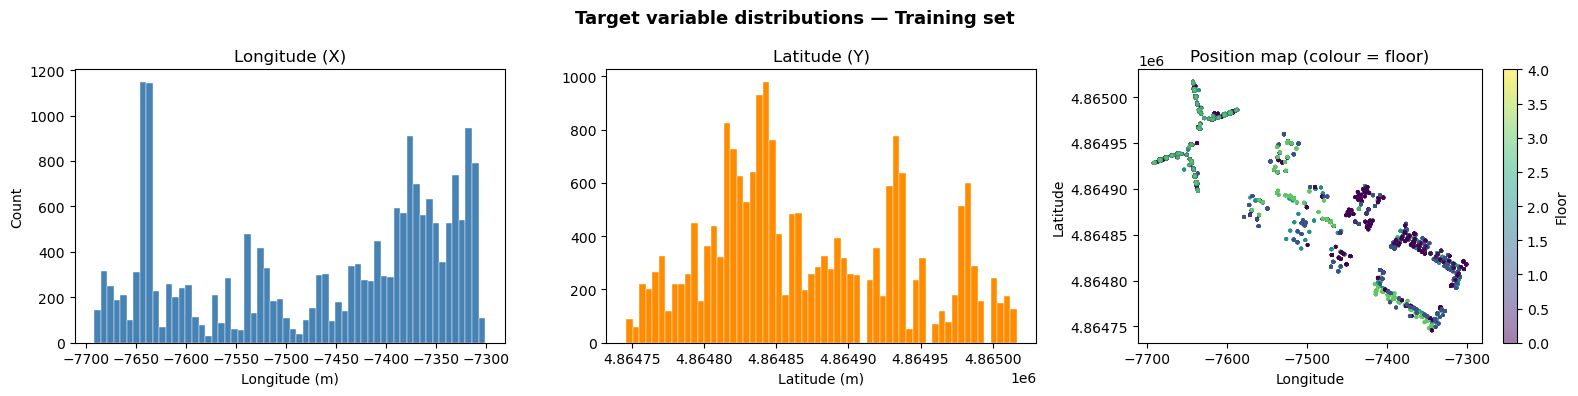

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Target variable distributions — Training set', fontsize=13, fontweight='bold')

axes[0].hist(train_df['LONGITUDE'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Longitude (X)')
axes[0].set_xlabel('Longitude (m)')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['LATITUDE'], bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
axes[1].set_title('Latitude (Y)')
axes[1].set_xlabel('Latitude (m)')

sc = axes[2].scatter(
    train_df['LONGITUDE'], train_df['LATITUDE'],
    c=train_df['FLOOR'], cmap='viridis', s=3, alpha=0.5
)
plt.colorbar(sc, ax=axes[2], label='Floor')
axes[2].set_title('Position map (colour = floor)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('phase1_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2.2  Building & floor counts

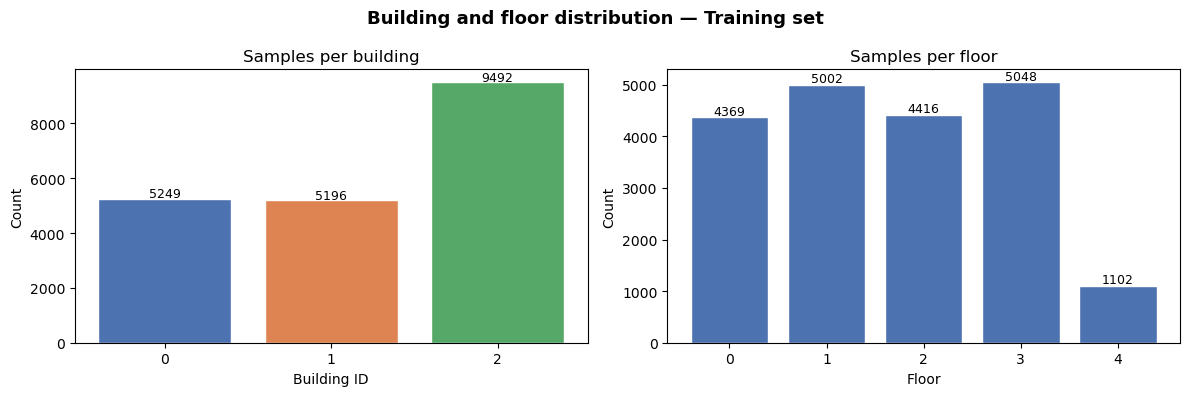

Samples per building:
 BUILDINGID
0    5249
1    5196
2    9492

Samples per floor:
 FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Building and floor distribution — Training set', fontsize=13, fontweight='bold')

building_counts = train_df['BUILDINGID'].value_counts().sort_index()
axes[0].bar(building_counts.index.astype(str), building_counts.values,
            color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[0].set_title('Samples per building')
axes[0].set_xlabel('Building ID')
axes[0].set_ylabel('Count')
for i, v in enumerate(building_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

floor_counts = train_df['FLOOR'].value_counts().sort_index()
axes[1].bar(floor_counts.index.astype(str), floor_counts.values,
            color='#4C72B0', edgecolor='white')
axes[1].set_title('Samples per floor')
axes[1].set_xlabel('Floor')
axes[1].set_ylabel('Count')
for i, v in enumerate(floor_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('phase1_building_floor_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print('Samples per building:\n', building_counts.to_string())
print('\nSamples per floor:\n', floor_counts.to_string())

### 1.2.3  RSSI signal analysis

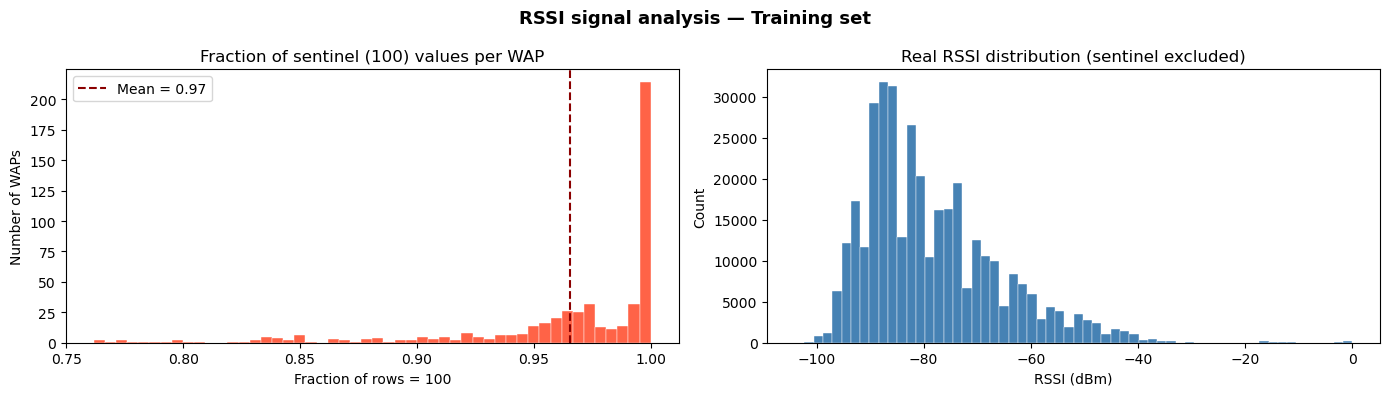

Total WAPs              : 520
Always-silent WAPs      : 55
Always-detected WAPs    : 0
Mean sentinel fraction  : 0.965
Real RSSI  min : -104.0 dBm
Real RSSI  max : 0.0 dBm
Real RSSI  mean: -78.5 dBm


In [8]:
rssi_matrix   = train_df[wap_cols]
sentinel_frac = (rssi_matrix == RSSI_SENTINEL).mean(axis=0)
real_vals     = rssi_matrix.values[rssi_matrix.values != RSSI_SENTINEL].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('RSSI signal analysis — Training set', fontsize=13, fontweight='bold')

axes[0].hist(sentinel_frac, bins=50, color='tomato', edgecolor='white', linewidth=0.3)
axes[0].axvline(sentinel_frac.mean(), color='darkred', linestyle='--',
                label=f'Mean = {sentinel_frac.mean():.2f}')
axes[0].set_title('Fraction of sentinel (100) values per WAP')
axes[0].set_xlabel('Fraction of rows = 100')
axes[0].set_ylabel('Number of WAPs')
axes[0].legend()

axes[1].hist(real_vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('Real RSSI distribution (sentinel excluded)')
axes[1].set_xlabel('RSSI (dBm)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('phase1_rssi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total WAPs              : {len(wap_cols)}')
print(f'Always-silent WAPs      : {(sentinel_frac == 1.0).sum()}')
print(f'Always-detected WAPs    : {(sentinel_frac == 0.0).sum()}')
print(f'Mean sentinel fraction  : {sentinel_frac.mean():.3f}')
print(f'Real RSSI  min : {real_vals.min():.1f} dBm')
print(f'Real RSSI  max : {real_vals.max():.1f} dBm')
print(f'Real RSSI  mean: {real_vals.mean():.1f} dBm')

### 1.2.4  WAP coverage heatmap (top-50 most active APs)

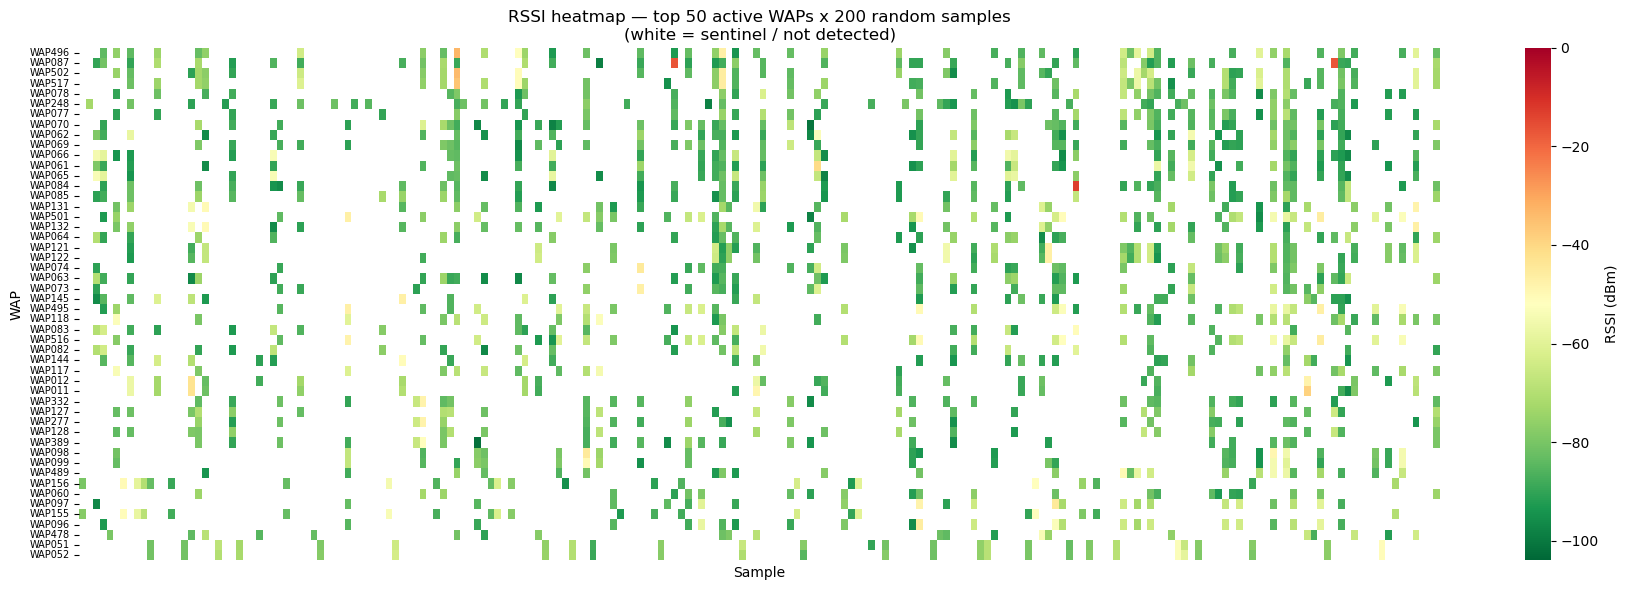

In [9]:
active_counts = (rssi_matrix != RSSI_SENTINEL).sum(axis=0).sort_values(ascending=False)
top50_waps    = active_counts.head(50).index.tolist()
sample_idx    = train_df.sample(200, random_state=RANDOM_SEED).index
heatmap_data  = rssi_matrix.loc[sample_idx, top50_waps].replace(RSSI_SENTINEL, np.nan)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    heatmap_data.T, ax=ax,
    cmap='RdYlGn_r', vmin=-104, vmax=0,
    cbar_kws={'label': 'RSSI (dBm)'},
    xticklabels=False, yticklabels=True
)
ax.set_title('RSSI heatmap — top 50 active WAPs x 200 random samples\n(white = sentinel / not detected)', fontsize=12)
ax.set_xlabel('Sample')
ax.set_ylabel('WAP')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig('phase1_rssi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.3  Preprocessing

### Sentinel handling strategy

Real RSSI values in this dataset are **negative** (e.g. −97, −83).  
The sentinel `100` means *AP not detected*.

We use a **zero-anchor encoding**:

| Step | Operation | Result |
|---|---|---|
| 1 | Add 105 to real RSSI | [−104, 0] → [1, 105] |
| 2 | Replace sentinel 100 with 0 | 0 = not detected |
| 3 | Divide by 105 | Final range [0, 1] |

This gives a clean `0 = not detected` with no ambiguity against real weak signals.

In [10]:
def preprocess_rssi(df: pd.DataFrame, cols: list) -> np.ndarray:
    """
    Normalise RSSI fingerprint matrix.
    Returns float32 array of shape (n_samples, len(cols)), values in [0, 1].
    """
    X = df[cols].values.astype(np.float32)
    real_mask    = (X != RSSI_SENTINEL)
    X[real_mask]  = X[real_mask] + 105.0   # shift: -104->1, 0->105
    X[~real_mask] = 0.0                    # sentinel -> 0
    X             = X / 105.0              # normalise to [0, 1]
    return X


X_train_full = preprocess_rssi(train_df, wap_cols)
X_val_full   = preprocess_rssi(val_df,   wap_cols)

print(f'X_train shape : {X_train_full.shape}')
print(f'Value range   : [{X_train_full.min():.3f}, {X_train_full.max():.3f}]')
print(f'Zero fraction : {(X_train_full == 0).mean():.3f}  (sentinel rows)')

X_train shape : (19937, 520)
Value range   : [0.000, 1.000]
Zero fraction : 0.965  (sentinel rows)


### 1.3.1  Verify preprocessing

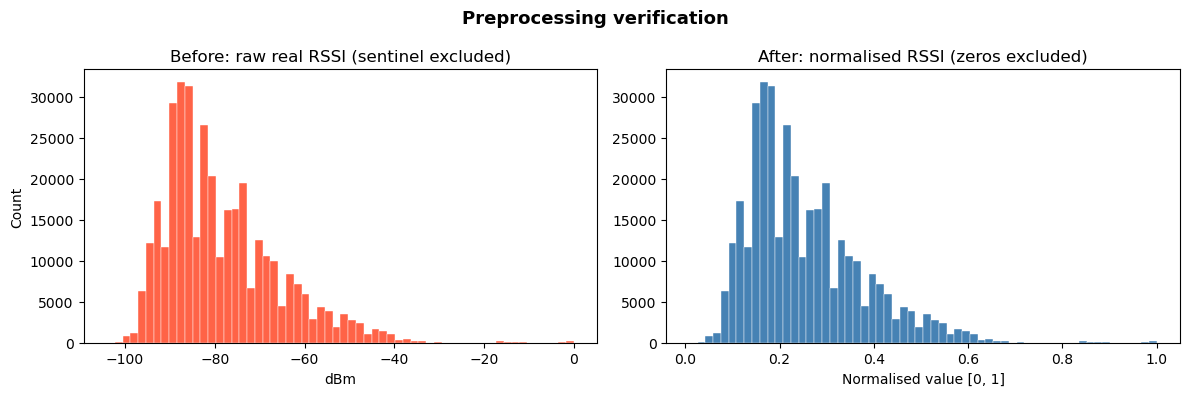

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Preprocessing verification', fontsize=13, fontweight='bold')

raw  = train_df[wap_cols].values.flatten()
axes[0].hist(raw[raw != RSSI_SENTINEL], bins=60,
             color='tomato', edgecolor='white', linewidth=0.3)
axes[0].set_title('Before: raw real RSSI (sentinel excluded)')
axes[0].set_xlabel('dBm')
axes[0].set_ylabel('Count')

proc = X_train_full.flatten()
axes[1].hist(proc[proc > 0], bins=60,
             color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title('After: normalised RSSI (zeros excluded)')
axes[1].set_xlabel('Normalised value [0, 1]')

plt.tight_layout()
plt.savefig('phase1_preprocessing_check.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3.2  Drop always-silent WAPs

In [12]:
always_silent   = (train_df[wap_cols] == RSSI_SENTINEL).all(axis=0)
active_wap_cols = [c for c in wap_cols if not always_silent[c]]

print(f'Always-silent WAPs removed : {always_silent.sum()}')
print(f'Active WAPs kept           : {len(active_wap_cols)}')

X_train   = preprocess_rssi(train_df, active_wap_cols)
X_val     = preprocess_rssi(val_df,   active_wap_cols)
INPUT_DIM = X_train.shape[1]

print(f'Final INPUT_DIM : {INPUT_DIM}')

Always-silent WAPs removed : 55
Active WAPs kept           : 465
Final INPUT_DIM : 465


### 1.3.3  Normalise coordinates (x, y)

In [13]:
y_train_raw = train_df[TARGET_COLS].values.astype(np.float32)
y_val_raw   = val_df[TARGET_COLS].values.astype(np.float32)

coord_scaler = MinMaxScaler()
y_train = coord_scaler.fit_transform(y_train_raw).astype(np.float32)
y_val   = coord_scaler.transform(y_val_raw).astype(np.float32)

print(f'y_train range : [{y_train.min():.4f}, {y_train.max():.4f}]')
print(f'y_val   range : [{y_val.min():.4f}, {y_val.max():.4f}]')
print(f'Longitude     : {coord_scaler.data_min_[0]:.2f} m  ->  {coord_scaler.data_max_[0]:.2f} m')
print(f'Latitude      : {coord_scaler.data_min_[1]:.2f} m  ->  {coord_scaler.data_max_[1]:.2f} m')


#Reason for Normaizing: Longitude values are around −7500 and latitude around 4,864,800 — completely different scales.
#If I fed those raw into MSE loss, the latitude term would dominate by a factor of millions just because its numbers are bigger, 
#and the model would barely learn longitude at all. 
#Normalising both to [0, 1] puts them on equal footing so the loss treats both coordinates fairly.

y_train range : [0.0000, 1.0000]
y_val   range : [-0.0118, 1.0039]
Longitude     : -7691.34 m  ->  -7300.82 m
Latitude      : 4864745.50 m  ->  4865016.50 m


---
## 1.4  Build PyTorch DataLoaders

In [14]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)

full_dataset = TensorDataset(X_train_t, y_train_t)
n_val_int    = int(len(full_dataset) * VAL_SPLIT)
n_train_int  = len(full_dataset) - n_val_int

train_dataset, val_int_dataset = random_split(
    full_dataset, [n_train_int, n_val_int],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)
test_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset,   batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_int_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False)

print('Dataset splits')
print(f'  Train (internal)     : {len(train_dataset):>6,}')
print(f'  Val   (internal)     : {len(val_int_dataset):>6,}')
print(f'  Test  (official val) : {len(test_dataset):>6,}')
print(f'\nBatches per epoch : {len(train_loader)}')
print(f'Input dimension   : {INPUT_DIM}')

Dataset splits
  Train (internal)     : 16,947
  Val   (internal)     :  2,990
  Test  (official val) :  1,111

Batches per epoch : 66
Input dimension   : 465


---
## 1.5  Save Everything for Phase 2

In [15]:
torch.save(X_train_t, 'X_train.pt')
torch.save(y_train_t, 'y_train.pt')
torch.save(X_val_t,   'X_val.pt')
torch.save(y_val_t,   'y_val.pt')

with open('coord_scaler.pkl', 'wb') as f:
    pickle.dump(coord_scaler, f)

config = {
    'input_dim'      : INPUT_DIM,
    'batch_size'     : BATCH_SIZE,
    'val_split'      : VAL_SPLIT,
    'random_seed'    : RANDOM_SEED,
    'target_cols'    : TARGET_COLS,
    'active_wap_cols': active_wap_cols,
    'coord_min'      : coord_scaler.data_min_.tolist(),
    'coord_max'      : coord_scaler.data_max_.tolist(),
    'rssi_sentinel'  : RSSI_SENTINEL,
}
with open('phase1_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved to notebook directory:')
print('  X_train.pt         — training features')
print('  y_train.pt         — training targets (normalised)')
print('  X_val.pt           — validation features')
print('  y_val.pt           — validation targets (normalised)')
print('  coord_scaler.pkl   — MinMaxScaler for inverse transform in Phase 4')
print('  phase1_config.json — config loaded by Phase 2+')

Saved to notebook directory:
  X_train.pt         — training features
  y_train.pt         — training targets (normalised)
  X_val.pt           — validation features
  y_val.pt           — validation targets (normalised)
  coord_scaler.pkl   — MinMaxScaler for inverse transform in Phase 4
  phase1_config.json — config loaded by Phase 2+
